# Machine Learning, DNN for regression

### Description of the dataset NO2
The dataset that we are going to use for this lesson was obtained from the StatLib repository. http://lib.stat.cmu.edu/datasets/ (NO2).
The data are a subsample of 500 observations from a data set that originate in a study where air pollution at a road is related to traffic volume and meteorological variables, collected by the Norwegian Public Roads Administration. The response variable (column 1) consist of hourly values of the logarithm of the concentration of NO2 (particles), measured at Alnabru in Oslo, Norway, between October 2001 and August 2003. The predictor variables (columns 2 to 8) are the logarithm of the number of cars per hour, temperature $2$ meters above ground (degree C), wind speed (meters/second), the temperature difference between $25$ and $2$ meters above ground (degree C), wind direction (degrees between 0 and 360), hour of day and day number from October 1 2001. Submitted by Magne Aldrin (magne.aldrin@nr.no). [28/Jul/04] (19kbytes) 


Target variable:
- NO2 concentration (log) [lno2]  

Features:    
- log of car per hour [lc] 

- temperature 2 meters above the ground (degree C)[t2] 

- wind speed (meters/seconds) [ws]

- temperature difference between 25 meters and 2 meters above the ground (degree C) [td25] 

- wind direction (degrees between 0 and 360) [wd] 

- hour of day [hd] average house occupancy

- day number from Oct. 1 2001 [dn] 

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from math import sqrt
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras import metrics

### ASSIGNING LABELS TO FEATURES
We assign the labels to the corresponding columns to have a clean representation of the dataset 


In [2]:
features = ['lc', 't2', 'ws', 'td25', 'wd', 'hd', 'dn']

### CREATE THE DNN LARGE NETWORK MODEL


<img src="images/DNN-all.png" alt="DNN Model Large" width="500"/>



In [3]:
def create_model_large():
    # create model
    model = Sequential()
    
    # create layers
    model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(30, activation='relu'))
    model.add(Dense(40, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[metrics.MeanAbsoluteError()])
    
    return model

### Create a DNN with 1 layer containing 3 neurons (model tiny)

In [4]:
def create_model_tiny():
    # create model
    model = Sequential()
    
    # create layers
    model.add(Dense(3, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[metrics.MeanAbsoluteError()])
    
    return model

#### Create a DNN with 1 layer containing 10 neurons (model small)

In [5]:
def create_model_small():
    # create model
    model = Sequential()
    
    # create layers
    model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[metrics.MeanAbsoluteError()])
    
    return model

#### Create a DNN with 2 layers containing respectively 10 and 30 neurons (model medium)

In [6]:
def create_model_medium():
    # create model
    model = Sequential()
    
    # create layers
    model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(30, activation='relu'))
    model.add(Dense(1))
    
    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[metrics.MeanAbsoluteError()])
    
    return model

### Evaluating the model

The following functions computes the Root Mean Squared Error and the Normalized Root Mean Squared Error between the groud thruth (real) and inferred (pred) responses

In [7]:
def RMSE(real, pred):
    return sqrt(mean_squared_error(real, pred))

def NRMSE(real, pred):
    return sqrt(mean_squared_error(real, pred)/(real.max() - real.min()))

### Loading  the data 

#### Using the panda library to load data, provide a descriptive summary

In [8]:
# Load data
df = pd.read_csv('NO2.csv', index_col=False)

# Descriptive statistics summary
df.describe()

,lno2,lc,t2,ws,td25,wd,hd,dn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,3.698368,6.973342,0.847400,3.056000,0.149400,143.370400,12.382000,310.474000
std,0.750597,1.087166,6.524636,1.784172,1.065237,86.510213,6.802693,200.977754
min,1.223780,4.127130,-18.600000,0.300000,-5.400000,2.000000,1.000000,32.000000
25%,3.213862,6.175842,-3.900000,1.675000,-0.200000,72.000000,6.000000,118.750000
50%,3.848020,7.425360,1.100000,2.800000,0.000000,97.000000,12.500000,212.000000
75%,4.216930,7.793175,4.900000,4.200000,0.600000,220.000000,18.000000,513.000000
max,6.395090,8.348540,21.100000,9.900000,4.300000,359.000000,24.000000,608.000000


### Visualzing the relationships among the features in the data

#### Compute and visualize a correlation matring among the features (using the seaborn library).

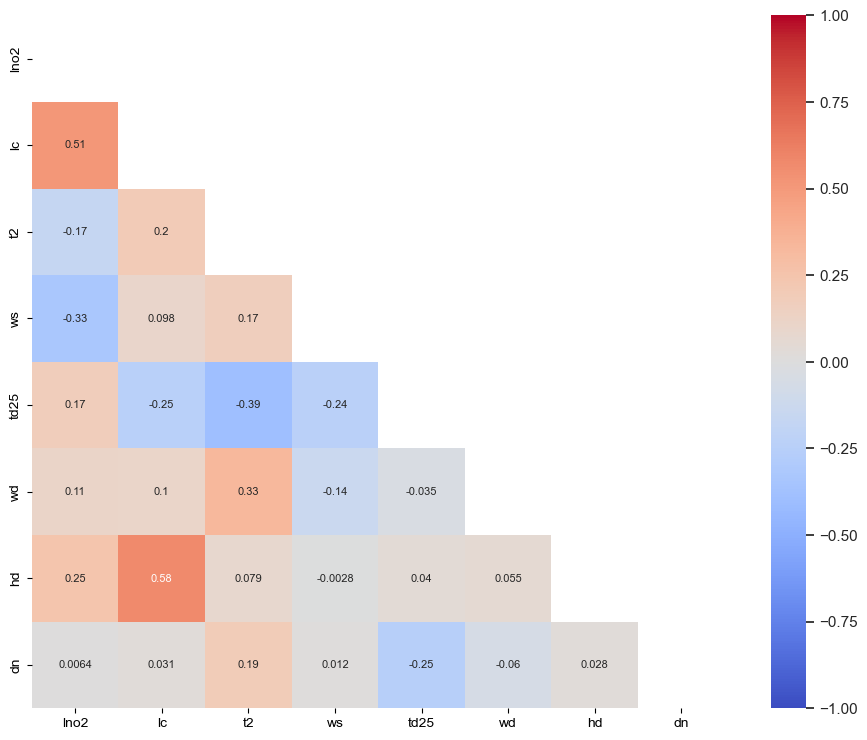

In [9]:
# Correlation matrix
corrmat = df.corr()

# Generate a mask for the upper triangle
matrix = np.triu(corrmat)
f, ax = plt.subplots(figsize=(12, 9))
sns.set(font_scale=1)
sns.heatmap(corrmat, vmin=-1, vmax=1, center= 0, square=True, annot=True, annot_kws={'size': 8}, mask=matrix, fmt='.2g', cmap= 'coolwarm')

plt.show()

### Standardizing the data

#### Standardize features to have 0 mean, sigma 1 and range between -1 and 1.  Do not standardize the response.

In [10]:
# Standardizing data
sc= MinMaxScaler(feature_range=(-1,1))

for var in features:
    if(var != 'lno2'):
        df[var] = sc.fit_transform(df[var].values.reshape(-1, 1))


### Preparing the data for training, using validation set approach 

In [11]:
#NumPy representation of the data frame (removing labels)
df = df.to_numpy() #df=df.values

#divide predictors from features
X = df[:, 1:]
y = df[:, 0]

seed = 7
np.random.seed(seed)

# split dataset in 75% for traininig and 25% for testing (500 -> 375,125)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed)

# split training in 70% for traininig and 30% for validating (375 -> 300,75)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=seed)

# Model creation (choose between tiny, small, medium and large by using the appropriate function)
model = create_model_large()
model.summary()

C:\Users\stepe\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │             330 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 40)                  │           1,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              41 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,691 (6.61 KB)

 Trainable params: 1,691 (6.61 KB)

 Non-trainable params: 0 (0.00 B)

### Fit the DNN to the data

In [12]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=150, batch_size=32)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 13.1748 - mean_absolute_error: 3.5453 - val_loss: 11.7129 - val_mean_absolute_error: 3.3495
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.6760 - mean_absolute_error: 3.1824 - val_loss: 9.0378 - val_mean_absolute_error: 2.9280
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.9878 - mean_absolute_error: 2.7267 - val_loss: 6.0616 - val_mean_absolute_error: 2.3640
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.0496 - mean_absolute_error: 2.1192 - val_loss: 3.1526 - val_mean_absolute_error: 1.6171
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4741 - mean_absolute_error: 1.3752 - val_loss: 1.2507 - val_mean_absolute_error: 0.8871
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2187 - mean_absolute_error: 0.9068 - val_loss: 0.9347 - val_mean_absolute_error: 0.7986
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0364 - mean_absolute_error: 0.8385 - val_

Epoch 51/150
11/11 [==============================] - 0s 3ms/step - loss: 0.2416 - mean_absolute_error: 0.3927 - val_loss: 0.2845 - val_mean_absolute_error: 0.4233
Epoch 52/150
11/11 [==============================] - 0s 3ms/step - loss: 0.2405 - mean_absolute_error: 0.3909 - val_loss: 0.2827 - val_mean_absolute_error: 0.4214
Epoch 53/150
11/11 [==============================] - 0s 3ms/step - loss: 0.2403 - mean_absolute_error: 0.3916 - val_loss: 0.2870 - val_mean_absolute_error: 0.4234
Epoch 54/150
11/11 [==============================] - 0s 3ms/step - loss: 0.2404 - mean_absolute_error: 0.3917 - val_loss: 0.2846 - val_mean_absolute_error: 0.4210
Epoch 55/150
11/11 [==============================] - 0s 3ms/step - loss: 0.2377 - mean_absolute_error: 0.3881 - val_loss: 0.2812 - val_mean_absolute_error: 0.4201
Epoch 56/150
11/11 [==============================] - 0s 3ms/step - loss: 0.2350 - mean_absolute_error: 0.3856 - val_loss: 0.2788 - val_mean_absolute_error: 0.4190
Epoch 57/150
11/

Epoch 101/150
11/11 [==============================] - 0s 3ms/step - loss: 0.1960 - mean_absolute_error: 0.3457 - val_loss: 0.2590 - val_mean_absolute_error: 0.4142
Epoch 102/150
11/11 [==============================] - 0s 3ms/step - loss: 0.1965 - mean_absolute_error: 0.3447 - val_loss: 0.2633 - val_mean_absolute_error: 0.4164
Epoch 103/150
11/11 [==============================] - 0s 3ms/step - loss: 0.1966 - mean_absolute_error: 0.3443 - val_loss: 0.2624 - val_mean_absolute_error: 0.4162
Epoch 104/150
11/11 [==============================] - 0s 3ms/step - loss: 0.1977 - mean_absolute_error: 0.3459 - val_loss: 0.2624 - val_mean_absolute_error: 0.4169
Epoch 105/150
11/11 [==============================] - 0s 4ms/step - loss: 0.1938 - mean_absolute_error: 0.3429 - val_loss: 0.2610 - val_mean_absolute_error: 0.4161
Epoch 106/150
11/11 [==============================] - 0s 3ms/step - loss: 0.1927 - mean_absolute_error: 0.3407 - val_loss: 0.2604 - val_mean_absolute_error: 0.4161
Epoch 107/

### Evaluate accuracy and loss of the model

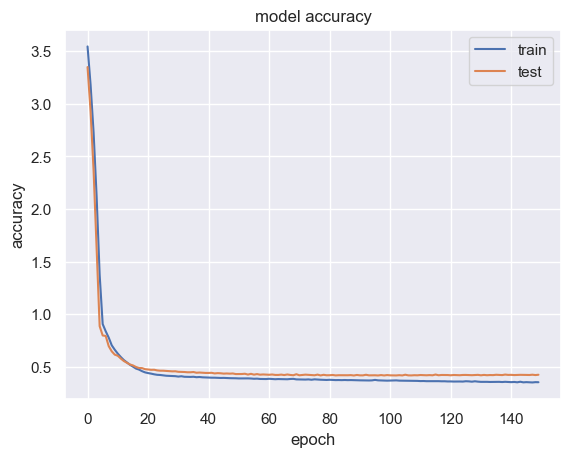

In [13]:
# Summarize history for accuracy
plt.plot(history.history['mean_absolute_error'])
plt.plot(history.history['val_mean_absolute_error'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

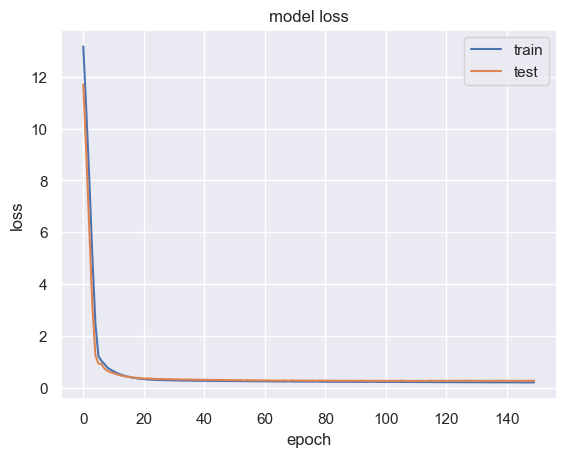

In [14]:
# Summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

### Now evaluate the predictions of the model in terms of RMSE and NRMSE

In [15]:
# Prediction
pred = model.predict(X_test).reshape(1,-1)[0]

rmse = RMSE(y_test, pred)
nrmse = NRMSE(y_test, pred)


print("rmse : ",rmse,"  nrmse : ",nrmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
rmse :  0.5215302866602081   nrmse :  0.2582500902190476


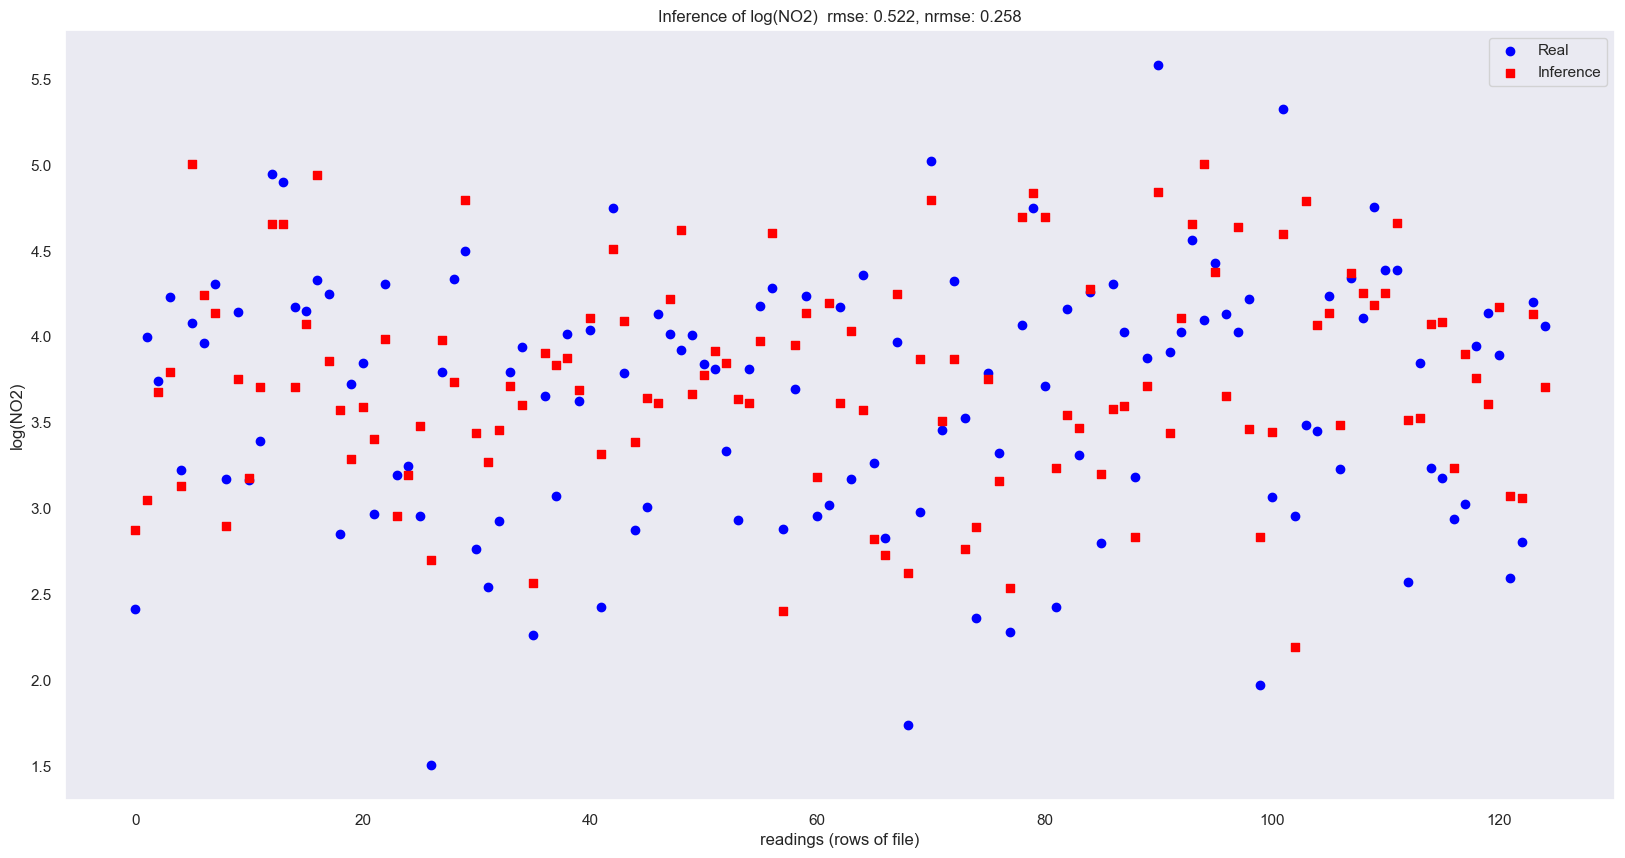

In [16]:
my_x=np.arange(0,len(X_test[:,0]),1)

fig = plt.figure(figsize=(20,10))
plt.scatter(my_x, y_test, label='Real', color='blue', marker='o')
plt.scatter(my_x, pred, label='Inference', color='red', marker='s')
plt.title(f'Inference of log(NO2)  rmse: {rmse:.3f}, nrmse: {nrmse:.3f}')
plt.ylabel('log(NO2)')
plt.xlabel('readings (rows of file)')
plt.grid()
plt.legend()
plt.show()

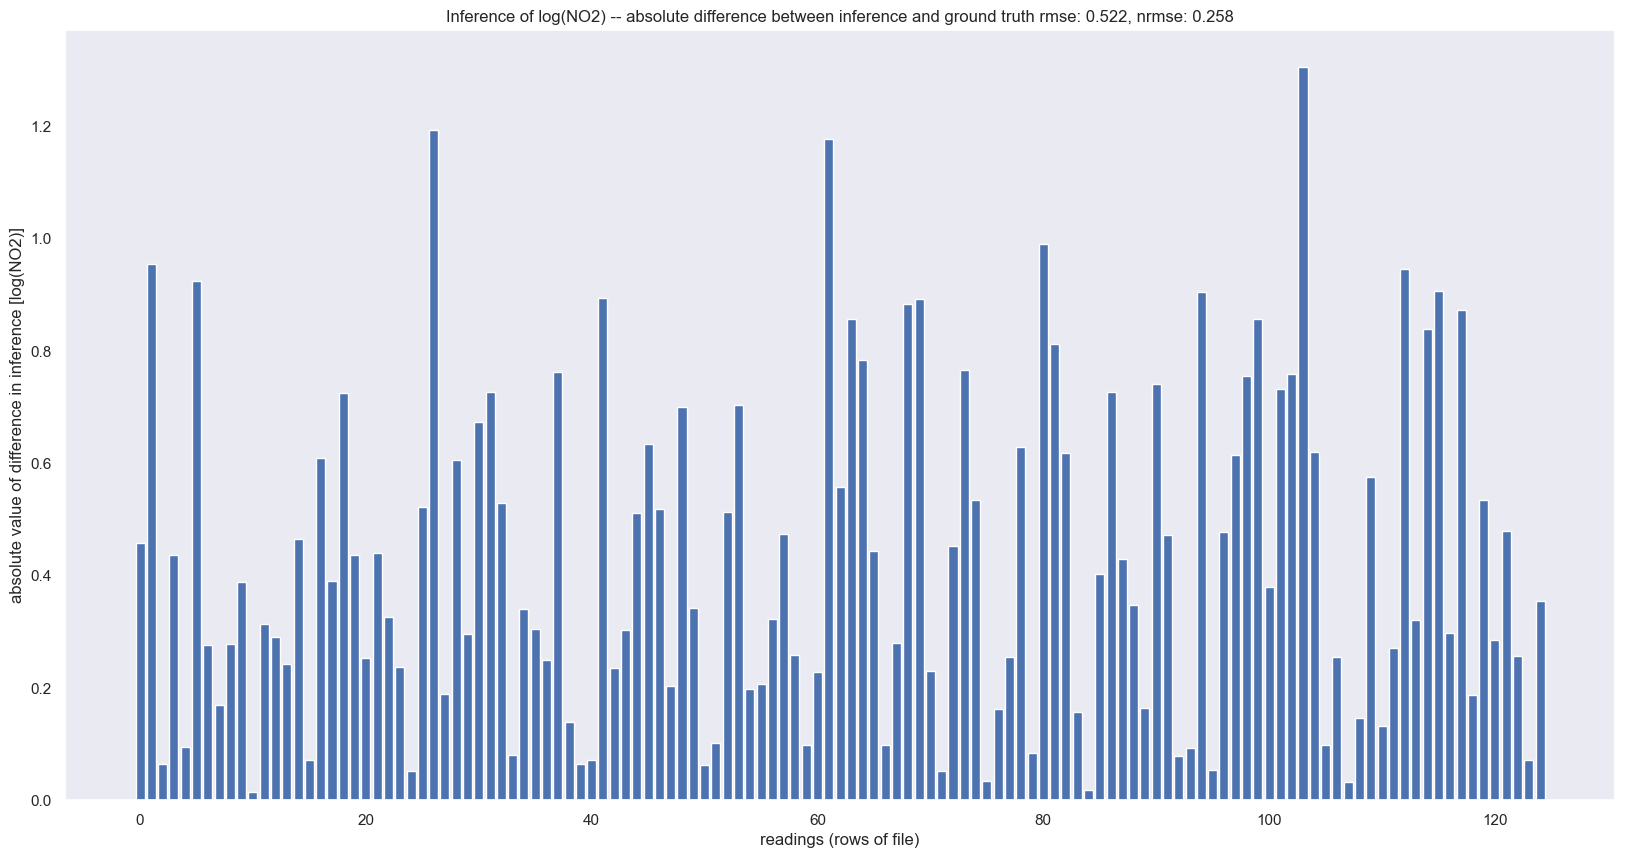

In [17]:
fig = plt.figure(figsize=(20,10))
my_d = abs(y_test-pred)

plt.bar(my_x,my_d)
plt.title(f'Inference of log(NO2) -- absolute difference between inference and ground truth rmse: {rmse:.3f}, nrmse: {nrmse:.3f}')
plt.ylabel('absolute value of difference in inference [log(NO2)]')
plt.xlabel('readings (rows of file)')
plt.grid()
plt.show()